In [1]:
import cv2
import numpy as np

from pathlib import Path
from random import sample
import numpy as np
from scipy.stats import norm
from scipy.optimize import curve_fit
from scipy.optimize import least_squares
from rtnls_enface.utils.plotting import mpl_grid
from vascx.fundus.loader import RetinaLoader
from matplotlib import pyplot as plt


In [2]:


ds_path = Path("../../samples/fundus")
loader = RetinaLoader.from_folder(ds_path)

Folder av_path: 6 files
Folder disc_path: 6 files
Folder fundus_path: 6 files
Folder vessels_path: 6 files


In [3]:
retina = loader[0]

<Axes: >

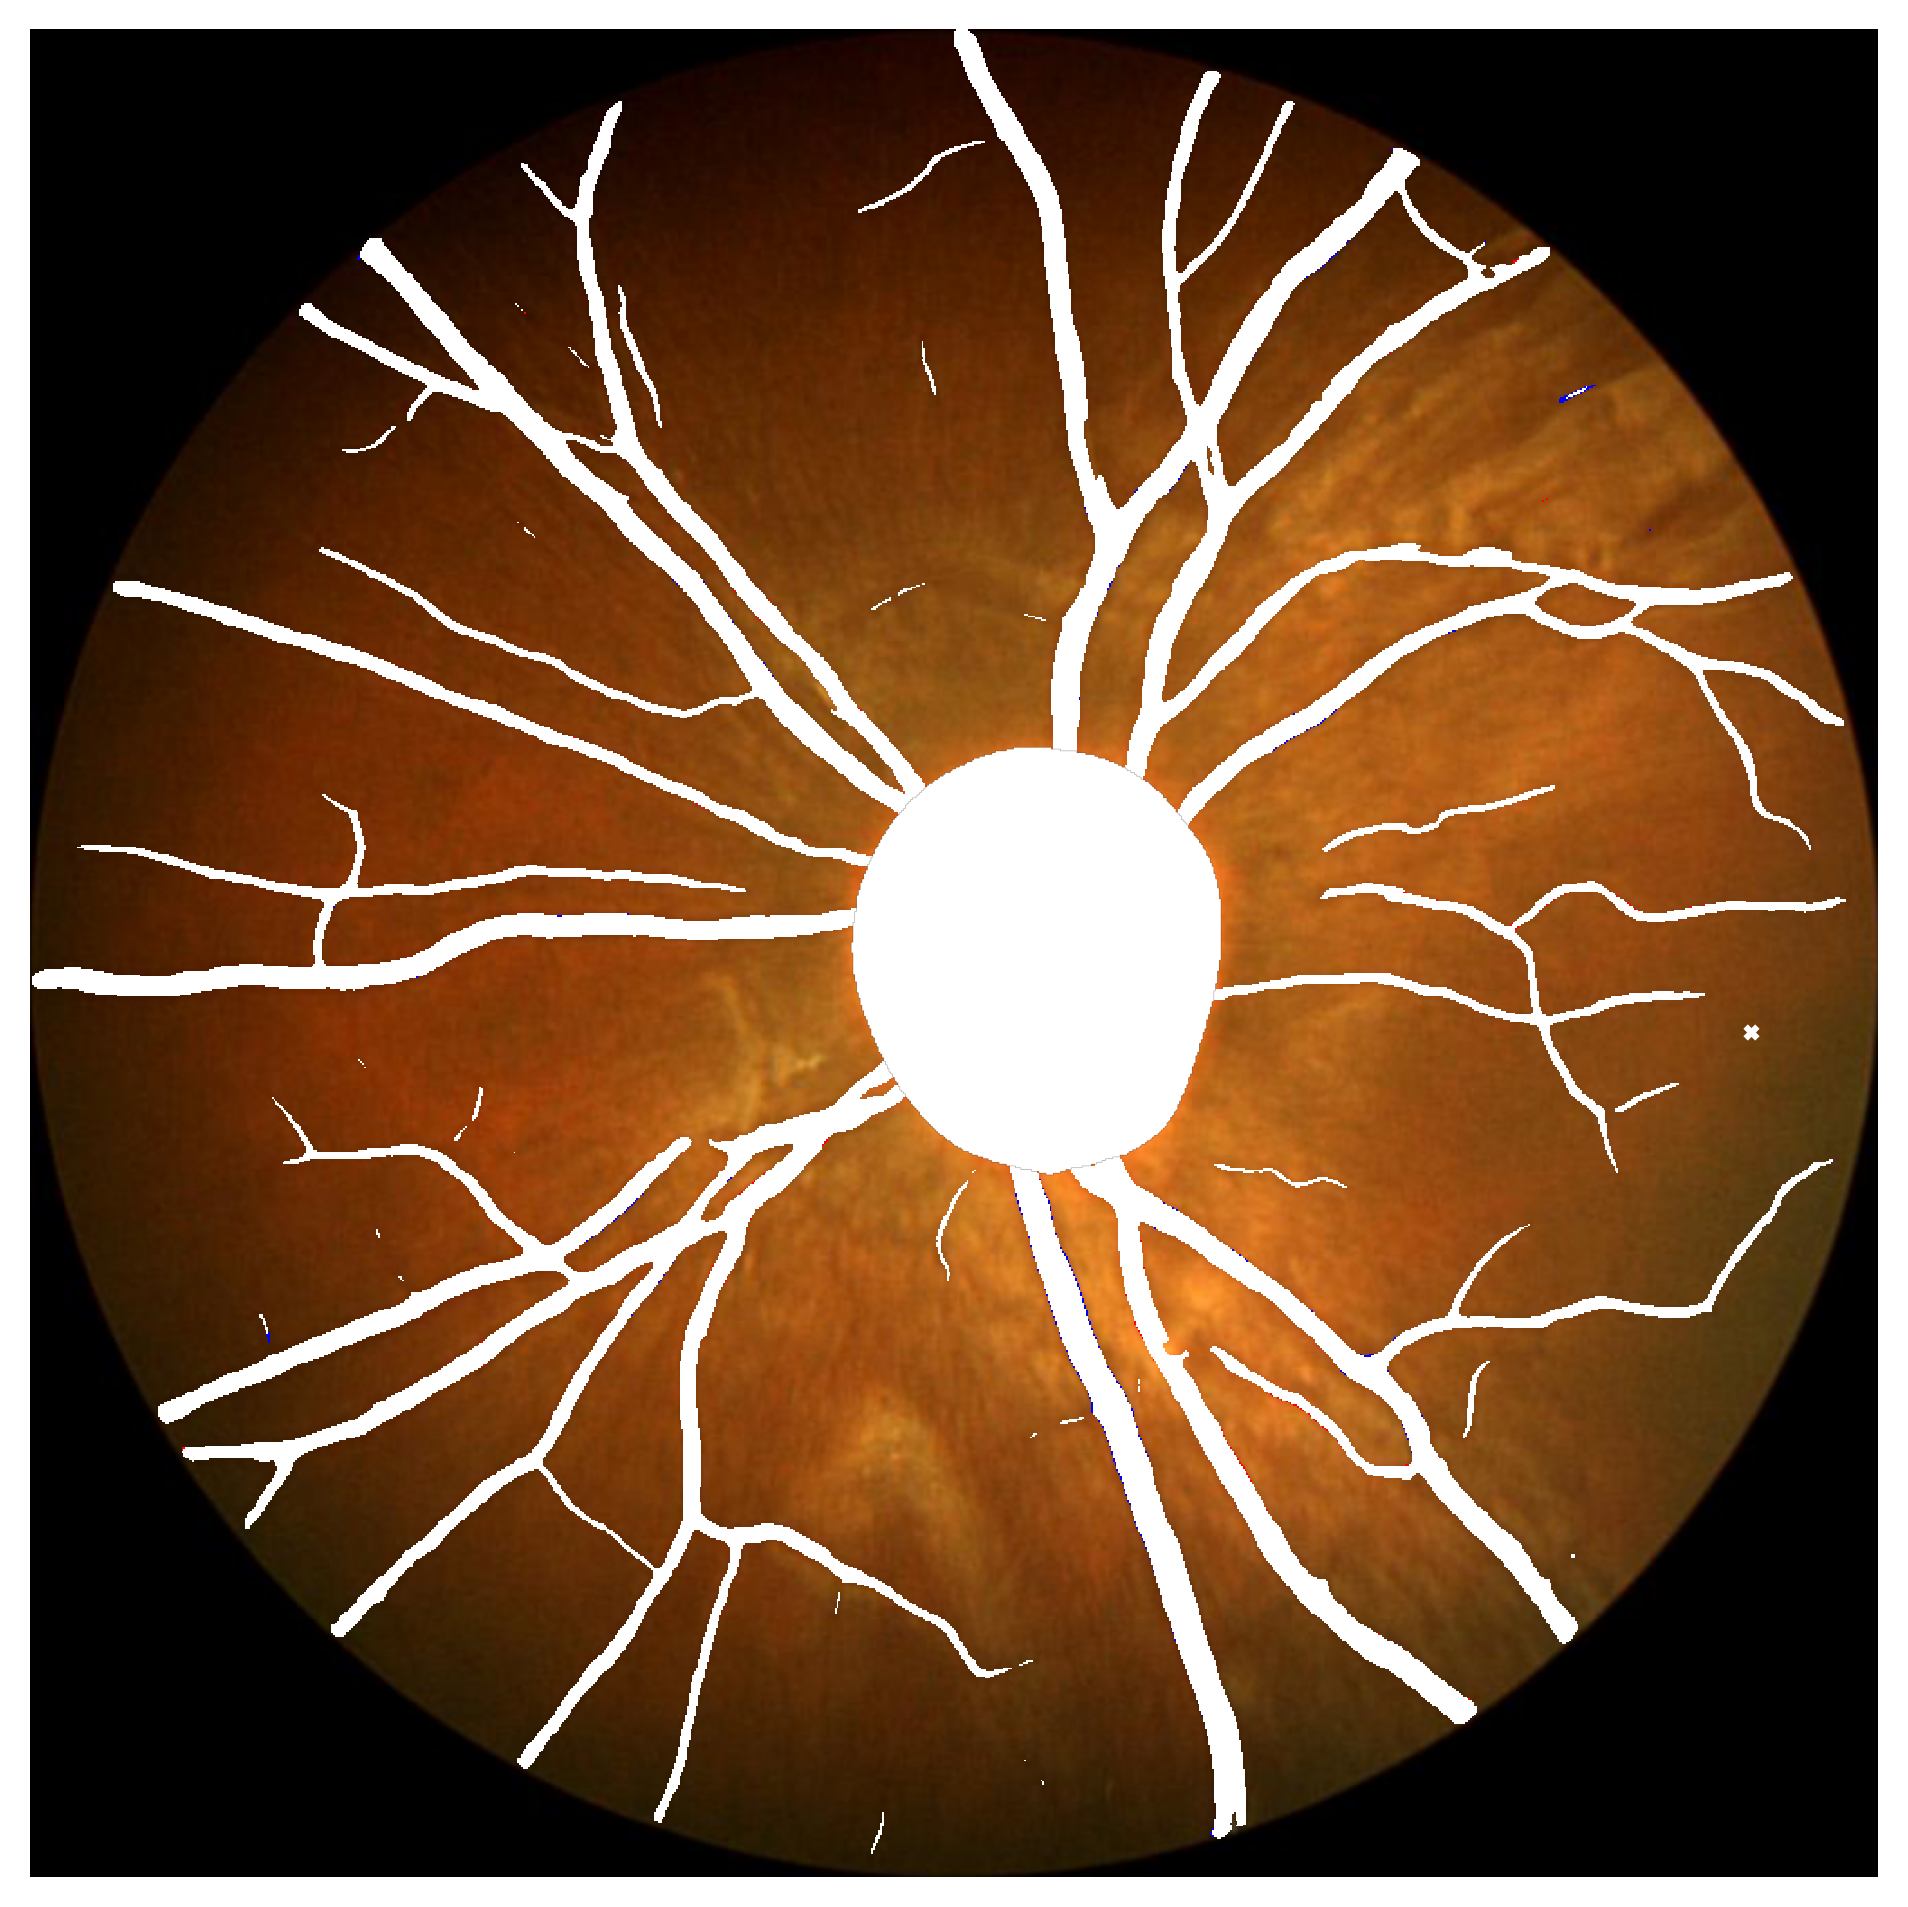

In [4]:
# retina.plot()

In [40]:
img = (retina.vessels.mask).astype(np.uint8) * 255
# Step 1: Compute the skeleton
skeleton = cv2.ximgproc.thinning(img)

# Step 2: Erode the original image
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
eroded = cv2.erode(img, kernel, iterations=3)

# Step 3: Combine erosion with skeleton to preserve connectivity
pruned = cv2.bitwise_or(eroded, skeleton)

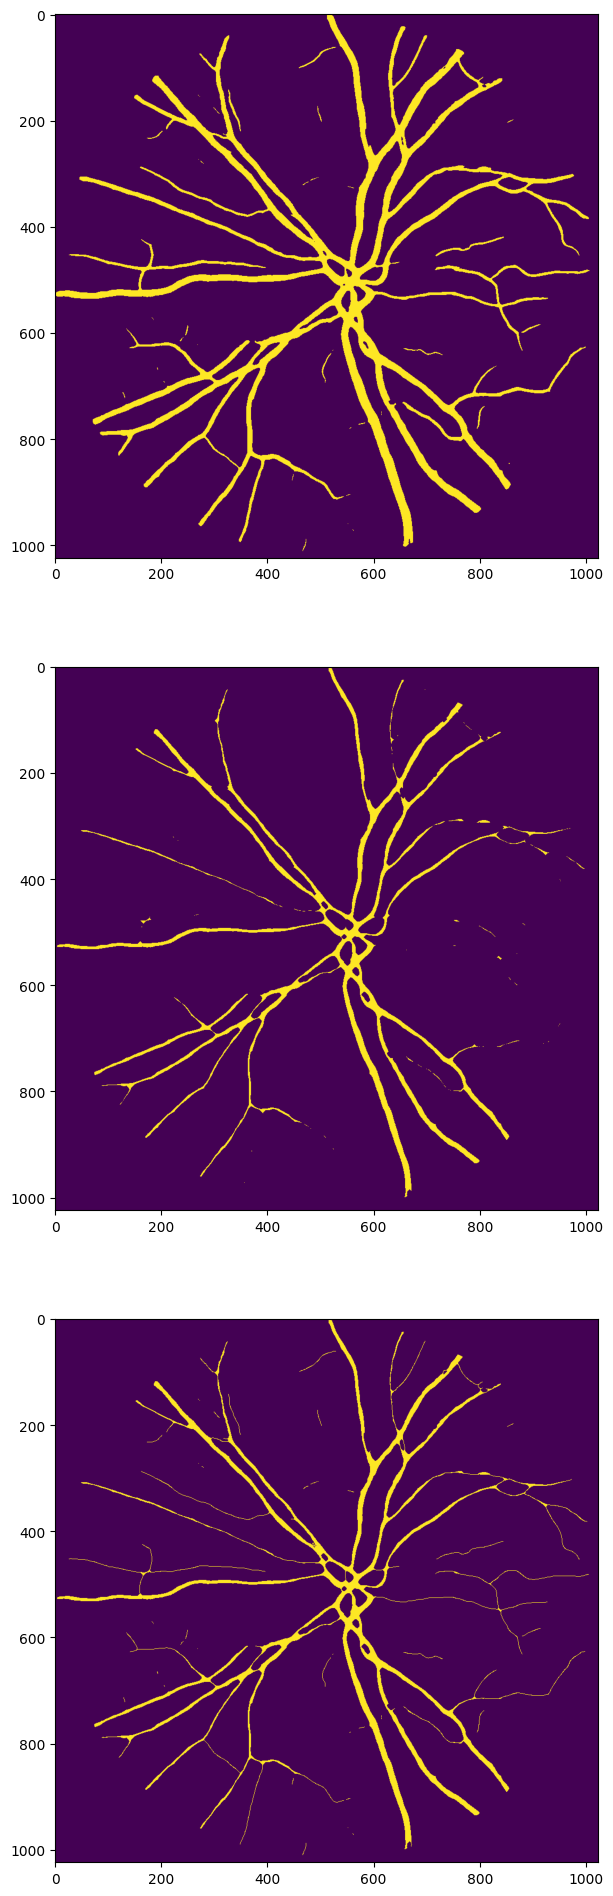

In [42]:
fig, ax = plt.subplots(3, 1, figsize=(24,24))
ax[0].imshow(img)
ax[1].imshow(eroded)
ax[2].imshow(pruned)
plt.show()

In [28]:
import cv2
import numpy as np
from scipy import ndimage as ndi     # pip install scipy

# 0-1 binary image -----------------------------------------------------------
img = (retina.vessels.mask).astype(np.uint8) * 255

# 1. skeleton of the original mask
skel = cv2.ximgproc.thinning(img)

# 2. prune with an erosion
kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
eroded  = cv2.erode(img, kernel, iterations=2)

# 3. label the objects that survived the erosion
labels, _ = ndi.label(eroded)              # 8-connectivity by default
labels = labels.astype(np.uint16)          # OpenCV likes uint16 for labels

# 4. candidate skeleton pixels = skeleton that was wiped out by the erosion
gap = cv2.bitwise_and(skel, cv2.bitwise_not(eroded))

# 5. enlarge the labelled regions by 1 px so a skeleton pixel
#    that touches the border “sees” the component it belongs to
labels_dil = cv2.dilate(labels, kernel, iterations=1)

# 6. keep a skeleton pixel only if it touches ≥ 2 different labels
needed = np.zeros_like(gap, np.uint8)
ys, xs  = np.where(gap)
for y, x in zip(ys, xs):
    win = labels_dil[max(0, y-1):y+2, max(0, x-1):x+2]
    neigh = np.unique(win[win > 0])
    if len(neigh) > 1:          # bridges two distinct eroded blobs
        needed[y, x] = 1

# 7. final result: eroded mask + “needed” skeleton pixels only
pruned = cv2.bitwise_or(eroded, needed)

In [30]:
np.min(img), np.max(img)

(np.uint8(0), np.uint8(255))

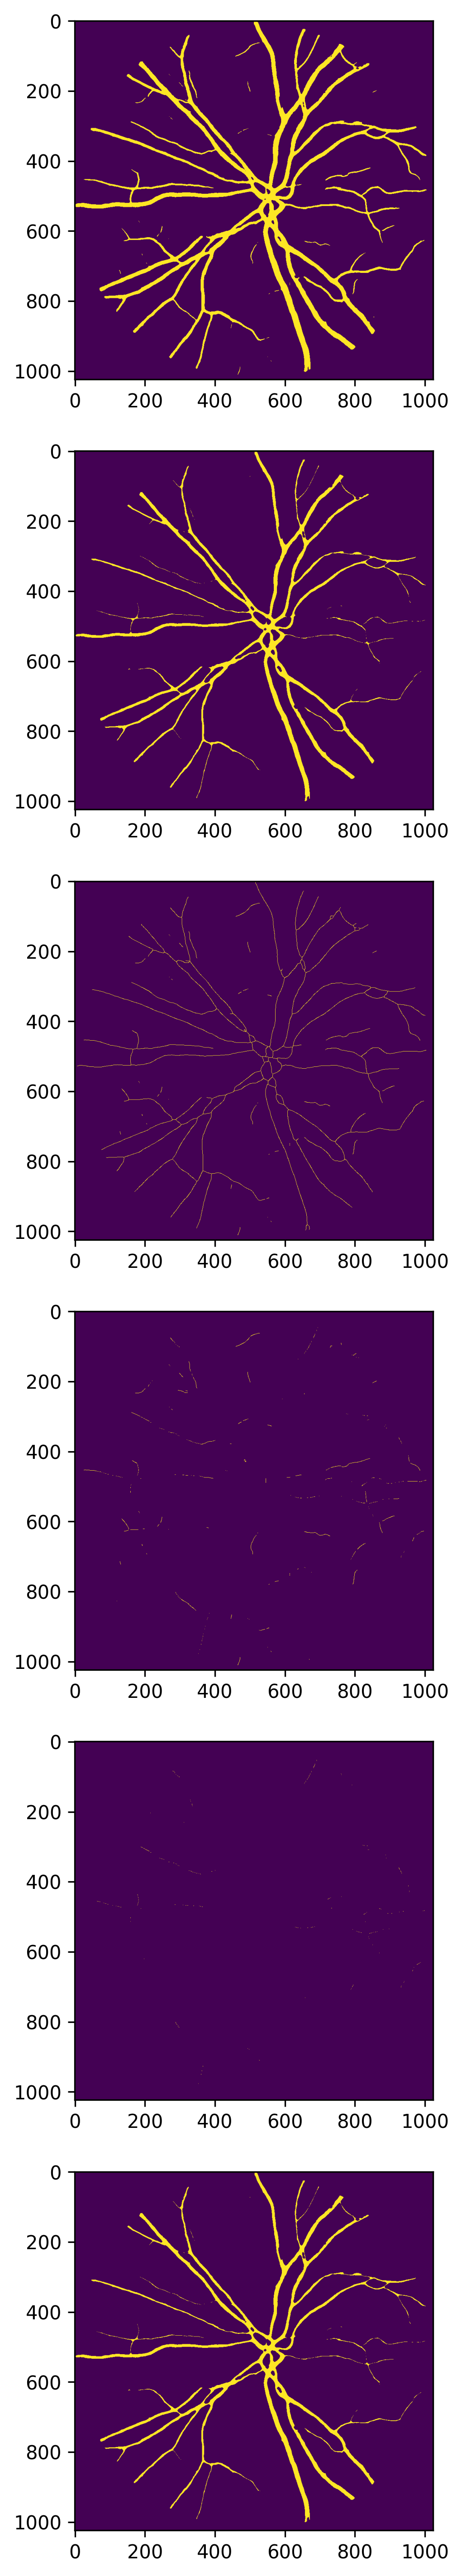

In [36]:
fig, ax = plt.subplots(6, 1, figsize=(24, 24), dpi=300)
ax[0].imshow(img)
ax[1].imshow(eroded)
ax[2].imshow(skel)
ax[3].imshow(gap)
ax[4].imshow(needed)
ax[5].imshow(pruned)
plt.show()